In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

event_types = ['Wedding', 'Corporate', 'Birthday', 'Anniversary', 'Party']

df = pd.DataFrame({
    'event_type': np.random.choice(event_types, n),
    'city': np.random.choice(['Bangalore', 'Mumbai', 'Delhi', 'Chennai', 'Hyderabad'], n),
    'guest_count': np.random.randint(20, 500, n),
    'budget_inr': np.random.randint(50000, 1500000, n),
    'duration_days': np.random.choice([1, 2, 3], n),
    'season': np.random.choice(['Summer', 'Winter', 'Monsoon'], n),
    'outdoor': np.random.choice([True, False], n)
})

df.to_csv('../data/events.csv', index=False)

print("Dataset created!")
print(f"Shape: {df.shape}")
print(df.head())

Dataset created!
Shape: (200, 7)
    event_type       city  guest_count  budget_inr  duration_days   season  \
0  Anniversary     Mumbai          163      567313              2   Winter   
1        Party      Delhi          454     1313108              1   Summer   
2     Birthday  Bangalore          105      662380              1  Monsoon   
3        Party  Bangalore          204     1415413              2   Summer   
4        Party    Chennai          304     1387682              2   Summer   

   outdoor  
0    False  
1     True  
2     True  
3     True  
4     True  


In [2]:
print("=== Event Type Counts ===")
print(df['event_type'].value_counts())

print("\n=== Average Budget by Event Type (INR) ===")
print(df.groupby('event_type')['budget_inr'].mean().sort_values(ascending=False))

=== Event Type Counts ===
event_type
Anniversary    49
Wedding        43
Birthday       37
Party          36
Corporate      35
Name: count, dtype: int64

=== Average Budget by Event Type (INR) ===
event_type
Birthday       871054.567568
Party          814760.500000
Corporate      803454.114286
Wedding        749747.186047
Anniversary    746170.061224
Name: budget_inr, dtype: float64


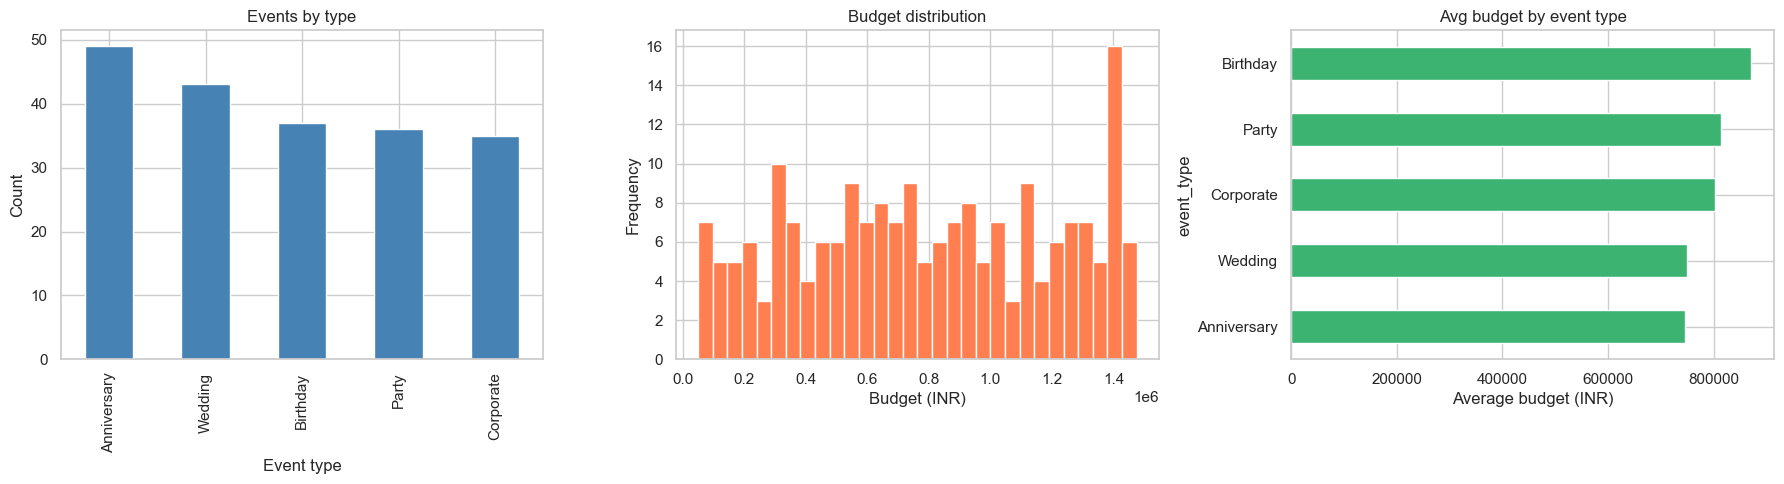

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['event_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Events by type')
axes[0].set_xlabel('Event type')
axes[0].set_ylabel('Count')

df['budget_inr'].plot(kind='hist', bins=30, ax=axes[1], color='coral')
axes[1].set_title('Budget distribution')
axes[1].set_xlabel('Budget (INR)')

df.groupby('event_type')['budget_inr'].mean().sort_values().plot(
    kind='barh', ax=axes[2], color='mediumseagreen'
)
axes[2].set_title('Avg budget by event type')
axes[2].set_xlabel('Average budget (INR)')

plt.tight_layout()
plt.savefig('../data/eda_charts.png')
plt.show()


In [5]:
# Smarter dataset where budget actually depends on inputs logically
np.random.seed(42)
n = 200

event_types = ['Wedding', 'Corporate', 'Birthday', 'Anniversary', 'Party']
cities = ['Bangalore', 'Mumbai', 'Delhi', 'Chennai', 'Hyderabad']

# Base budget per event type (realistic Indian prices)
base_budget = {
    'Wedding': 800000,
    'Corporate': 600000,
    'Birthday': 300000,
    'Anniversary': 400000,
    'Party': 250000
}

# City multiplier (Mumbai/Delhi are more expensive)
city_multiplier = {
    'Mumbai': 1.4,
    'Delhi': 1.3,
    'Bangalore': 1.2,
    'Hyderabad': 1.0,
    'Chennai': 1.0
}

rows = []
for _ in range(n):
    event = np.random.choice(event_types)
    city = np.random.choice(cities)
    guests = np.random.randint(20, 500)
    duration = np.random.choice([1, 2, 3])
    season = np.random.choice(['Summer', 'Winter', 'Monsoon'])
    outdoor = np.random.choice([True, False])

    # Budget now logically depends on all these factors
    budget = (
        base_budget[event]
        * city_multiplier[city]
        + guests * 1500          # each guest adds ₹1500
        + duration * 50000       # each extra day adds ₹50000
        + (30000 if outdoor else 0)
        + np.random.randint(-50000, 50000)  # small random noise
    )

    rows.append([event, city, guests, int(budget), duration, season, outdoor])

df = pd.DataFrame(rows, columns=[
    'event_type', 'city', 'guest_count', 'budget_inr',
    'duration_days', 'season', 'outdoor'
])

df.to_csv('../data/events.csv', index=False)
print("Smarter dataset saved!")
print(df.head())

Smarter dataset saved!
    event_type       city  guest_count  budget_inr  duration_days   season  \
0  Anniversary  Hyderabad          290     1019886              3   Summer   
1    Corporate      Delhi          234     1275131              3  Monsoon   
2     Birthday  Hyderabad          277      770811              2   Winter   
3  Anniversary  Hyderabad          180      843016              2   Winter   
4      Wedding      Delhi           78     1259747              3   Winter   

   outdoor  
0     True  
1    False  
2    False  
3     True  
4    False  
